## Module import

In [1]:
import os, site, sys
import tensorflow as tf 
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications import Xception
from sklearn.metrics import classification_report
from tensorflow.keras import Model
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D

2025-04-30 11:35:32.384636: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746027332.396108 3185888 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746027332.399466 3185888 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
BASE_DIR = "/projectnb/ds340/projects/MS"
train_df = pd.read_csv(os.path.join(BASE_DIR, "train.csv"))
val_df   = pd.read_csv(os.path.join(BASE_DIR, "valid.csv"))
test_df  = pd.read_csv(os.path.join(BASE_DIR, "test.csv"))

## Data Preprocessing

In [3]:
def plot_original_images(path, set_, num_images=5):
    dir_ = os.path.join(path, 'train', set_)
    file_paths = [os.path.join(dir_, file_name) for file_name in os.listdir(dir_)[:num_images]]

    plt.figure(figsize=(10, 5))
    for i, file_path in enumerate(file_paths):
        img = load_img(file_path, target_size=(256, 256))
        plt.subplot(2, num_images, i + 1)
        plt.imshow(img)
        plt.title(f"{set_} - Original")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

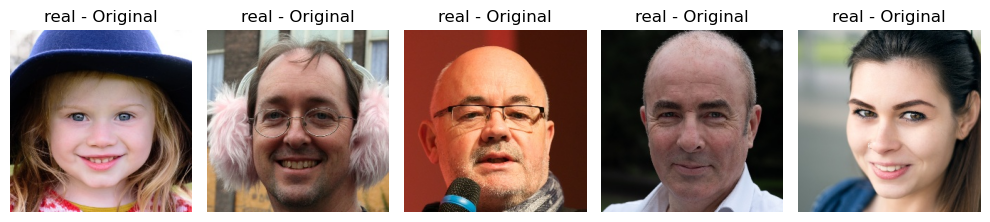

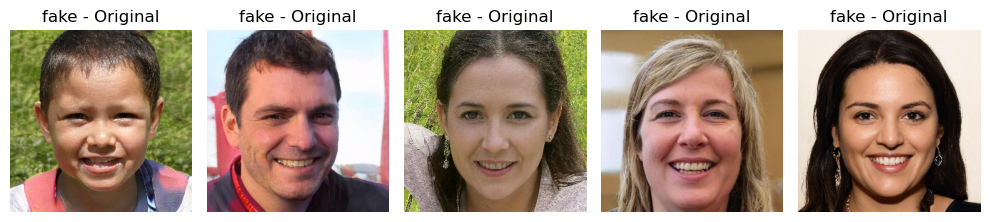

In [4]:
inner = os.listdir(os.path.join(BASE_DIR, "real_vs_fake"))[0]
base_path = os.path.join(BASE_DIR, "real_vs_fake", inner)

plot_original_images(base_path, "real")
plot_original_images(base_path, "fake")

In [5]:
print(len(train_df), len(test_df), len(val_df))

100000 20000 20000


In [6]:
# 20k train / 3k val / 3k test, stratified
train_small, _ = train_test_split(
    train_df, train_size=20_000,
    stratify=train_df["label_str"],
    random_state=42
)
val_small, _ = train_test_split(
    val_df, train_size=3_000,
    stratify=val_df["label_str"],
    random_state=42
)
test_small, _ = train_test_split(
    test_df, train_size=3_000,
    stratify=test_df["label_str"],
    random_state=42
)

In [7]:
print("Train small distribution:\n", train_small['label_str'].value_counts(), "\n")
print("Test small distribution:\n", test_small['label_str'].value_counts(), "\n")
print("Validation small distribution:\n", val_small['label_str'].value_counts(), "\n")

Train small distribution:
 label_str
fake    10000
real    10000
Name: count, dtype: int64 

Test small distribution:
 label_str
fake    1500
real    1500
Name: count, dtype: int64 

Validation small distribution:
 label_str
fake    1500
real    1500
Name: count, dtype: int64 



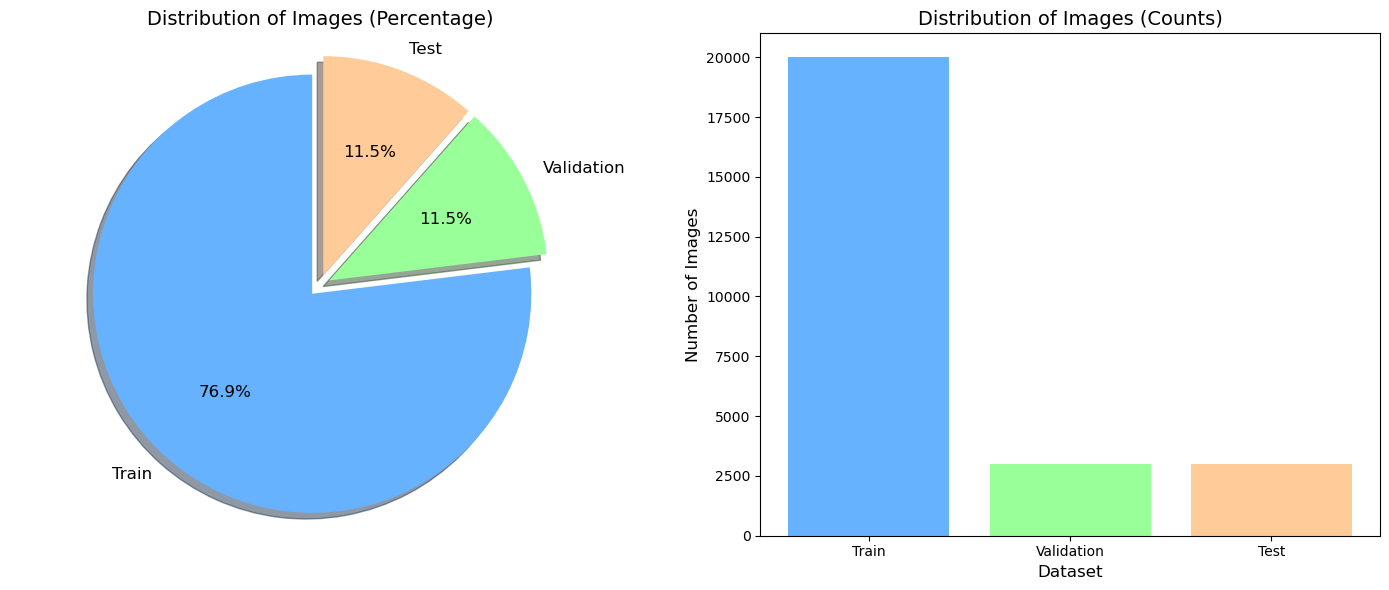

In [8]:
labels = ["Train", "Validation", "Test"]
counts = [
    len(train_small),  
    len(val_small),   
    len(test_small) 
]
colors = ['#66b2ff', '#99ff99', '#ffcc99']
explode = (0.05, 0.05, 0.05)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
ax1.pie(
    counts,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=90,
    textprops={'fontsize': 12}
)
ax1.set_title("Distribution of Images (Percentage)", fontsize=14)
ax1.axis('equal')

# Bar chart
ax2.bar(labels, counts, color=colors)
ax2.set_xlabel('Dataset', fontsize=12)
ax2.set_ylabel('Number of Images', fontsize=12)
ax2.set_title('Distribution of Images (Counts)', fontsize=14)

plt.tight_layout()
plt.show()

## Data Augmentation Comparison

#### CNN Baseline

In [9]:
def build_baseline_model(input_shape=(224, 224, 3)):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D(),
        
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(),
    
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [10]:
# rescale
baseline_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator_small = baseline_datagen.flow_from_dataframe(
    dataframe=train_small,
    directory=base_path,
    x_col="path",
    y_col="label_str",
    target_size=(224, 224),
    batch_size=64,
    shuffle=True,
    class_mode="binary"
)

val_generator_small = baseline_datagen.flow_from_dataframe(
    dataframe=val_small,
    directory=base_path,
    x_col="path",
    y_col="label_str",
    target_size=(224, 224),
    batch_size=64,
    shuffle=False,
    class_mode="binary"
)

Found 20000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.


In [11]:
model_baseline = build_baseline_model()

/share/pkg.8/academic-ml/spring-2025/install/spring-2025-tf/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1745967895.796126 2056343 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14784 MB memory:  -> device: 0, name: Tesla V100-SXM2-16GB, pci bus id: 0000:af:00.0, compute capability: 7.0


In [80]:
history_baseline = model_baseline.fit(
    train_generator_small,
    validation_data=val_generator_small,
    epochs=10
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.6563 - loss: 0.6244 - val_accuracy: 0.7347 - val_loss: 0.5180
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.7667 - loss: 0.4864 - val_accuracy: 0.7860 - val_loss: 0.4549
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.8195 - loss: 0.3892 - val_accuracy: 0.8360 - val_loss: 0.3801
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 306ms/step - accuracy: 0.8762 - loss: 0.2870 - val_accuracy: 0.8537 - val_loss: 0.3555
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.9170 - loss: 0.2073 - val_accuracy: 0.8543 - val_loss: 0.3583
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.9444 - loss: 0.1457 - val_accuracy: 0.8683 - val_loss: 0.3565
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.9620 - loss: 0.1023 - val_accuracy: 0.8810 - val_loss: 0.3269
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9666 - loss: 0.0873 -

In [81]:
all_histories = {}

In [82]:
all_histories['baseline'] = history_baseline

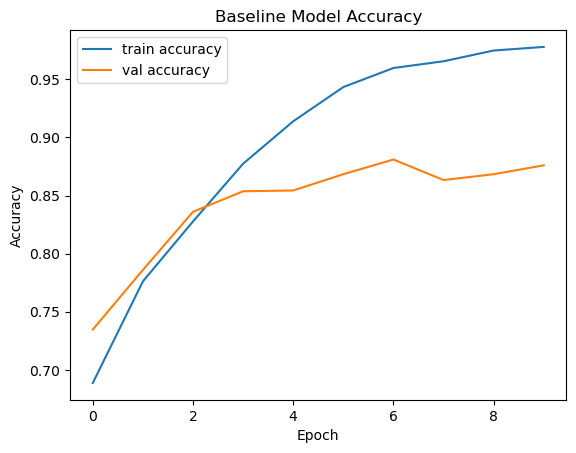

In [83]:
plt.plot(history_baseline.history['accuracy'], label='train accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='val accuracy')
plt.title('Baseline Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Horizontal Flip

In [84]:
flip_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True  
)

In [85]:
train_generator_flip = flip_datagen.flow_from_dataframe(
    dataframe=train_small,
    directory=base_path,
    x_col='path',      
    y_col='label_str',  
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

val_generator_flip = flip_datagen.flow_from_dataframe(
    dataframe=val_small,
    directory=base_path,
    x_col='path',
    y_col='label_str',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 20000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.


In [87]:
model_flip = build_baseline_model()

history_flip = model_flip.fit(
    train_generator_flip,
    validation_data=val_generator_flip,
    epochs=10
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - accuracy: 0.5696 - loss: 0.6948 - val_accuracy: 0.6770 - val_loss: 0.6056
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.7229 - loss: 0.5511 - val_accuracy: 0.7423 - val_loss: 0.5405
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.7638 - loss: 0.4860 - val_accuracy: 0.7773 - val_loss: 0.4665
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.8005 - loss: 0.4312 - val_accuracy: 0.7813 - val_loss: 0.4752
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.8247 - loss: 0.3945 - val_accuracy: 0.8107 - val_loss: 0.4208
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.8511 - loss: 0.3390 - val_accuracy: 0.8103 - val_loss: 0.4187
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.8766 - loss: 0.2971 - val_accuracy: 0.8227 - val_loss: 0.4146
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.8939 - loss: 0.2541 - 

In [88]:
all_histories['flip'] = history_flip

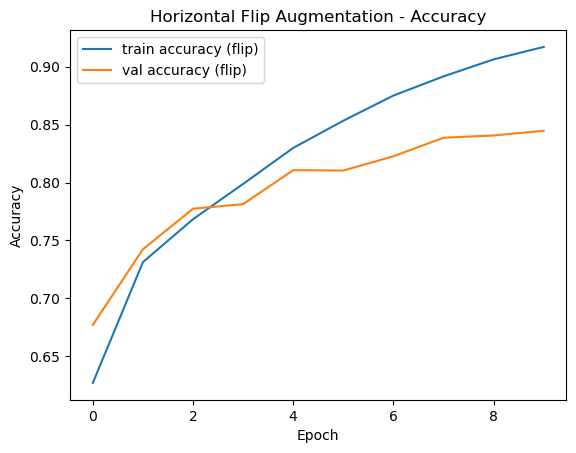

In [89]:
plt.plot(history_flip.history['accuracy'], label='train accuracy (flip)')
plt.plot(history_flip.history['val_accuracy'], label='val accuracy (flip)')
plt.title('Horizontal Flip Augmentation - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Rotation Augmentation

In [90]:
rotation_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20  
)

In [91]:
train_generator_rotation = rotation_datagen.flow_from_dataframe(
    dataframe=train_small,
    directory=base_path,
    x_col='path',       
    y_col='label_str', 
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

val_generator_rotation = rotation_datagen.flow_from_dataframe(
    dataframe=val_small,
    directory=base_path,
    x_col='path',
    y_col='label_str',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 20000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.


In [94]:
rotation_model = build_baseline_model(input_shape=(224, 224, 3))

In [95]:
history_rotation = rotation_model.fit(
    train_generator_rotation,
    epochs=10,
    validation_data=val_generator_rotation,
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 128s 202ms/step - accuracy: 0.5770 - loss: 0.7141 - val_accuracy: 0.6387 - val_loss: 0.6383
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 128s 205ms/step - accuracy: 0.6564 - loss: 0.6159 - val_accuracy: 0.6723 - val_loss: 0.5917
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 207ms/step - accuracy: 0.6919 - loss: 0.5864 - val_accuracy: 0.7127 - val_loss: 0.5536
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 202ms/step - accuracy: 0.7264 - loss: 0.5439 - val_accuracy: 0.7320 - val_loss: 0.5236
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 230ms/step - accuracy: 0.7481 - loss: 0.5179 - val_accuracy: 0.7493 - val_loss: 0.4988
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 134s 214ms/step - accuracy: 0.7672 - loss: 0.4840 - val_accuracy: 0.7690 - val_loss: 0.4936
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 235ms/step - accuracy: 0.7954 - loss: 0.4466 - val_accuracy: 0.7743 - val_loss: 0.4877
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 127s 204ms/step - accuracy: 0.8033 -

In [96]:
all_histories['rotation'] = history_rotation

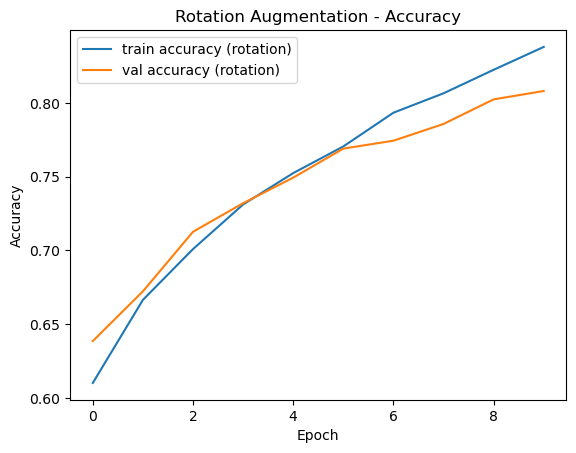

In [97]:
plt.plot(history_rotation.history['accuracy'], label='train accuracy (rotation)')
plt.plot(history_rotation.history['val_accuracy'], label='val accuracy (rotation)')
plt.title('Rotation Augmentation - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Gaussian Noise

In [55]:
def add_gaussian_noise(img):
    img = img.astype(np.float32)
    mean, stddev = 0.0, 25.0                 # noise in pixel space
    noise = np.random.normal(mean, stddev, img.shape)
    noisy = img + noise
    return np.clip(noisy, 0., 255.) 

In [56]:
train_noise_datagen = ImageDataGenerator(
    preprocessing_function=add_gaussian_noise, 
    rescale=1./255  
)
val_noise_datagen = ImageDataGenerator(
    rescale=1./255 
)

In [57]:
train_generator_noise = train_noise_datagen.flow_from_dataframe(
    dataframe=train_small,
    directory=base_path,
    x_col='path',       
    y_col='label_str', 
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

val_generator_noise = val_noise_datagen.flow_from_dataframe(
    dataframe=val_small,
    directory=base_path,
    x_col='path',
    y_col='label_str',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 20000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.


In [64]:
noise_model = build_baseline_model()

history_noise = noise_model.fit(
    train_generator_noise,
    epochs=10,
    validation_data=val_generator_noise
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 100s 159ms/step - accuracy: 0.5090 - loss: 0.7396 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 156ms/step - accuracy: 0.5338 - loss: 0.6846 - val_accuracy: 0.6817 - val_loss: 0.6064
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 156ms/step - accuracy: 0.6798 - loss: 0.6041 - val_accuracy: 0.7037 - val_loss: 0.5697
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 156ms/step - accuracy: 0.7317 - loss: 0.5382 - val_accuracy: 0.7330 - val_loss: 0.5357
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 157ms/step - accuracy: 0.7639 - loss: 0.4881 - val_accuracy: 0.7517 - val_loss: 0.5172
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 155ms/step - accuracy: 0.7891 - loss: 0.4424 - val_accuracy: 0.7593 - val_loss: 0.4897
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.8146 - loss: 0.4008 - val_accuracy: 0.7707 - val_loss: 0.4994
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 157ms/step - accuracy: 0.8425 - loss: 

In [65]:
all_histories['gaussian_noise'] = history_noise

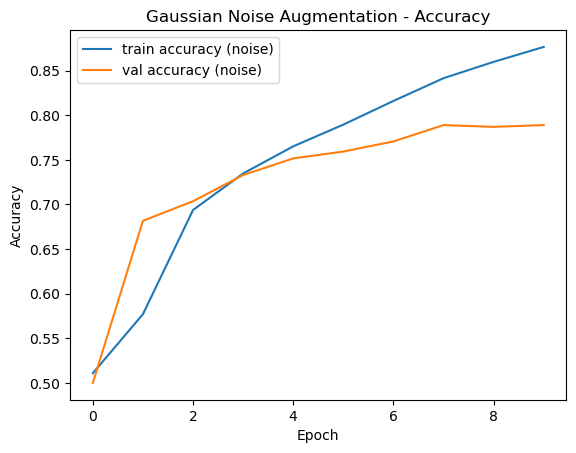

In [66]:
plt.plot(history_noise.history['accuracy'], label='train accuracy (noise)')
plt.plot(history_noise.history['val_accuracy'], label='val accuracy (noise)')
plt.title('Gaussian Noise Augmentation - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

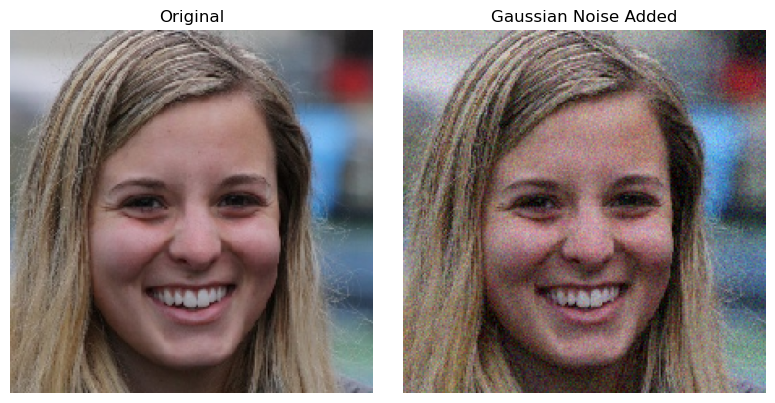

In [64]:
# Randomly fetch one image from the training generator
img, label = next(train_generator_baseline)  # Use the baseline generator to fetch a clean image
img = img[0]  # Take the first image from the batch

# Apply Gaussian noise to the image
noisy_img = add_gaussian_noise(img)

# Plot the original vs. the noisy image
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(noisy_img)
plt.title('Gaussian Noise Added')
plt.axis('off')

plt.tight_layout()
plt.show()


### JPEG Compression Artifacts

In [67]:
import cv2

In [68]:
def jpeg_compression(img):
    img_uint8 = img.astype(np.uint8)
    _, enc = cv2.imencode('.jpg', img_uint8, [cv2.IMWRITE_JPEG_QUALITY, 50])
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return dec.astype(np.float32) 

In [69]:
train_jpeg_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=jpeg_compression
)
val_jpeg_datagen = ImageDataGenerator(
    rescale=1./255)    

In [70]:
train_generator_jpeg = train_jpeg_datagen.flow_from_dataframe(
    dataframe=train_small,
    directory=base_path,
    x_col='path',       
    y_col='label_str', 
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

val_generator_jpeg = val_jpeg_datagen.flow_from_dataframe(
    dataframe=val_small,
    directory=base_path,
    x_col='path',
    y_col='label_str',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 20000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.


In [72]:
jpeg_model = build_baseline_model()

history_jpeg = jpeg_model.fit(
    train_generator_jpeg,
    epochs=10,
    validation_data=val_generator_jpeg,
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 68ms/step - accuracy: 0.5901 - loss: 0.6821 - val_accuracy: 0.6920 - val_loss: 0.5950
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.7230 - loss: 0.5568 - val_accuracy: 0.7460 - val_loss: 0.5073
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.7826 - loss: 0.4599 - val_accuracy: 0.7497 - val_loss: 0.5265
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 59ms/step - accuracy: 0.8343 - loss: 0.3701 - val_accuracy: 0.7937 - val_loss: 0.4478
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.8823 - loss: 0.2800 - val_accuracy: 0.8287 - val_loss: 0.4184
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.9191 - loss: 0.1991 - val_accuracy: 0.8177 - val_loss: 0.4432
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.9355 - loss: 0.1635 - val_accuracy: 0.8193 - val_loss: 0.5139
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.9501 - loss: 0.1247 - 

In [73]:
all_histories['jpeg_compression'] = history_jpeg

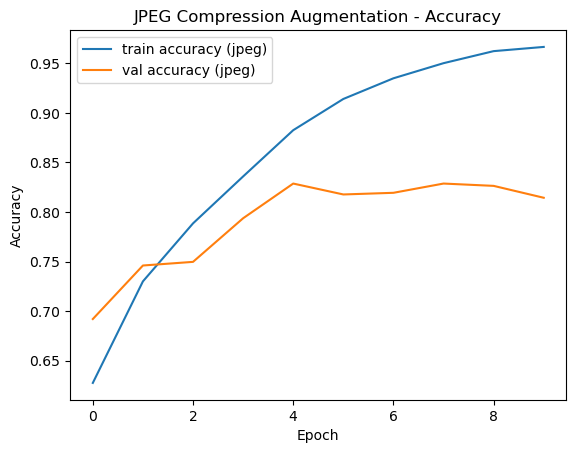

In [74]:
plt.plot(history_jpeg.history['accuracy'], label='train accuracy (jpeg)')
plt.plot(history_jpeg.history['val_accuracy'], label='val accuracy (jpeg)')
plt.title('JPEG Compression Augmentation - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

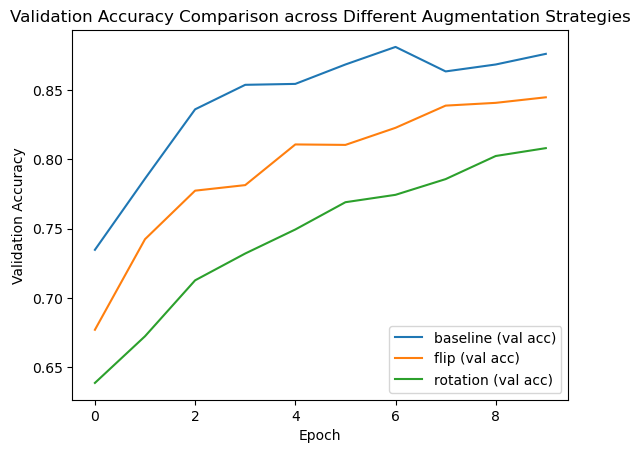

In [98]:
for strategy_name, history in all_histories.items():
    plt.plot(history.history['val_accuracy'], label=f'{strategy_name} (val acc)')

plt.title('Validation Accuracy Comparison across Different Augmentation Strategies')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

## Data Augmentation

In [9]:
gen_data = ImageDataGenerator(
    rescale=1./255.,
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    brightness_range=(0.9,1.1),
    channel_shift_range=5,
    horizontal_flip=True,
    fill_mode='reflect'
)

In [10]:
def make_gen(df, batch_size=64, shuffle=True):
    return gen_data.flow_from_dataframe(
        dataframe=df,
        directory=base_path,
        x_col="path",
        y_col="label_str",
        target_size=(256,256),
        color_mode="rgb",
        class_mode="binary",
        batch_size=batch_size,
        shuffle=shuffle,
    )

In [11]:
train_gen = make_gen(train_small, batch_size=64, shuffle=True)
val_gen   = make_gen(val_small,   batch_size=64, shuffle=False)
test_gen  = make_gen(test_small,  batch_size=64, shuffle=False)

Found 20000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.


In [12]:
# Define the ImageDataGenerator for EfficientNetB0 training set 
gen_data_224 = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    brightness_range=(0.9, 1.1),
    channel_shift_range=5,
    horizontal_flip=True,
    fill_mode='reflect'
)

val_test_datagen224 = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)


def make_gen224(df, batch_size=64, shuffle=True):
    return gen_data_224.flow_from_dataframe(
        dataframe=df,
        directory=base_path,
        x_col="path",
        y_col="label_str",
        target_size=(224, 224),   
        color_mode="rgb",
        class_mode="binary",
        batch_size=batch_size,
        shuffle=shuffle,
    )


# new Generator
train_gen224 = make_gen224(train_small, batch_size=64, shuffle=True)
val_gen224 = make_gen224(val_small, batch_size=64, shuffle=False)
test_gen224 = make_gen224(test_small, batch_size=64, shuffle=False)

Found 20000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.46541178..0.59239614].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48501962..0.46007845].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4614902..0.4404706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.44580394..0.51498044].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47325492..0.44439217].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48501962..0.44729805].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range 

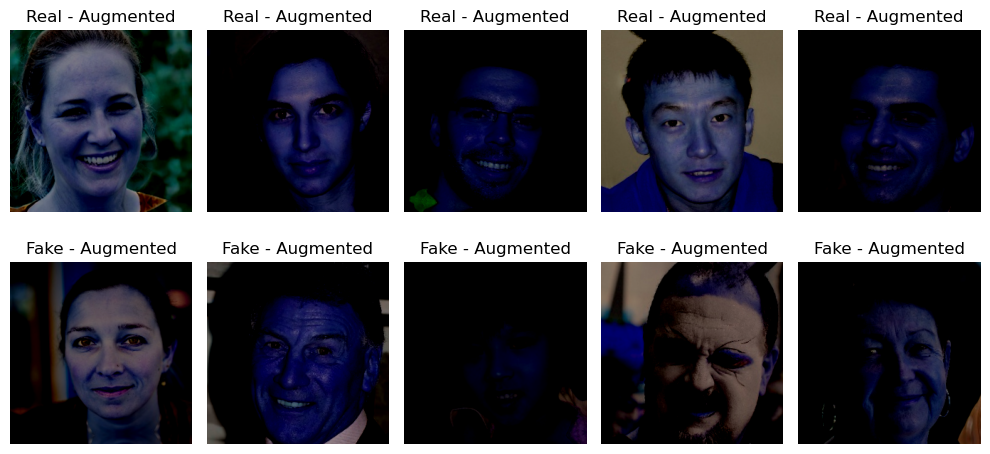

In [13]:
images, labels = next(train_gen)

real_images = images[labels == 0]
fake_images = images[labels == 1]

# Plot 5 real/fake images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(real_images[i])
    plt.title("Real - Augmented")
    plt.axis('off')
for i in range(5):
    plt.subplot(2, 5, i + 6)
    plt.imshow(fake_images[i])
    plt.title("Fake - Augmented")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Model Preparation

In [14]:
# Check GPU Availability
print("GPUs Available:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())

GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


## Model Training

### CNN

In [ ]:
model_cnn = Sequential()
model_cnn.add(Conv2D(32,kernel_size=(3, 3), activation='relu', input_shape=(256, 256, 3)))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Dropout(0.2))
model_cnn.add(Flatten())
model_cnn.add(Dense(64, activation='relu'))
model_cnn.add(Dropout(0.2))
model_cnn.add(Dense(1, activation='sigmoid'))
model_cnn.summary()

In [ ]:
model_cnn.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
history_c = model_cnn.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,)

In [ ]:
test_loss, test_accuracy = model_cnn.evaluate(test_gen)
print(f'Loss: {test_loss}, Accuracy: {test_accuracy}')

In [ ]:
plt.plot(history_c.history['loss'], label='train loss')
plt.plot(history_c.history['val_loss'], label='validation loss')
plt.legend()
plt.show()


plt.plot(history_c.history['accuracy'], label='train accuracy')
plt.plot(history_c.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 539ms/step


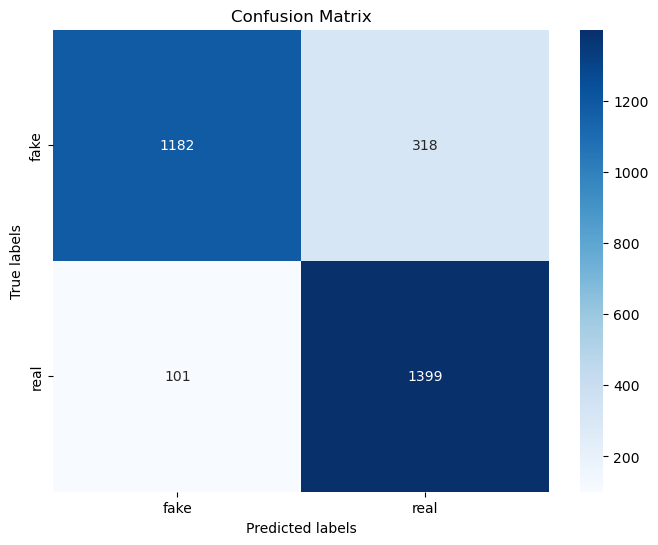

In [45]:
predictions = model_cnn.predict(test_gen)
predicted_labels = np.where(predictions > 0.5, 1, 0)
true_labels = test_gen.classes

conf_matrix = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices,
            yticklabels=test_gen.class_indices)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [46]:
class_names = list(test_gen.class_indices.keys())
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

        fake       0.92      0.79      0.85      1500
        real       0.81      0.93      0.87      1500

    accuracy                           0.86      3000
   macro avg       0.87      0.86      0.86      3000
weighted avg       0.87      0.86      0.86      3000



### XceptionNet

In [14]:
base_model = Xception(weights='imagenet',include_top=False,input_shape=(256, 256, 3))

I0000 00:00:1746027416.952071 3185888 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43500 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:e1:00.0, compute capability: 8.9


In [15]:
for layer in base_model.layers:
    layer.trainable = False

Xception_model = Sequential()
Xception_model.add(base_model)
Xception_model.add(Flatten())
Xception_model.add(BatchNormalization())
Xception_model.add(Dense(256, activation='relu'))
Xception_model.add(Dropout(0.5))
Xception_model.add(Dense(128, activation='relu'))
Xception_model.add(Dropout(0.5))
Xception_model.add(BatchNormalization())
Xception_model.add(Dense(1, activation='sigmoid'))
Xception_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 8, 8, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 131072)         │       524,288 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,973,993 (209.71 MB)

 Trainable params: 33,850,113 (129.13 MB)

 Non-trainable params: 21,123,880 (80.58 MB)

In [16]:
Xception_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [17]:
history_x = Xception_model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,)

/share/pkg.8/academic-ml/spring-2025/install/spring-2025-tf/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1746027424.995754 3186700 service.cc:148] XLA service 0x147a3c014860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746027424.995776 3186700 service.cc:156]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
I0000 00:00:1746027425.580506 3186700 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1746027429.132589 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746027429.243918 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746027430.007656 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746027430.106001 318670

  1/313 ━━━━━━━━━━━━━━━━━━━━ 50:59 10s/step - accuracy: 0.5156 - loss: 0.9349

I0000 00:00:1746027431.976250 3186700 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


185/313 ━━━━━━━━━━━━━━━━━━━━ 1:18 616ms/step - accuracy: 0.6300 - loss: 0.7214

E0000 00:00:1746027547.566017 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746027547.658483 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746027548.102830 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746027548.196002 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.6437 - loss: 0.6932  

E0000 00:00:1746027655.761008 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746027655.869280 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746027656.561164 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746027656.658428 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


313/313 ━━━━━━━━━━━━━━━━━━━━ 236s 724ms/step - accuracy: 0.6438 - loss: 0.6930 - val_accuracy: 0.7613 - val_loss: 0.5050
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 199s 635ms/step - accuracy: 0.7487 - loss: 0.5302 - val_accuracy: 0.7847 - val_loss: 0.4495
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 197s 629ms/step - accuracy: 0.7764 - loss: 0.4677 - val_accuracy: 0.7967 - val_loss: 0.4189
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 196s 627ms/step - accuracy: 0.8028 - loss: 0.4286 - val_accuracy: 0.8123 - val_loss: 0.4063
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 196s 625ms/step - accuracy: 0.8200 - loss: 0.3952 - val_accuracy: 0.8227 - val_loss: 0.3956
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 198s 632ms/step - accuracy: 0.8311 - loss: 0.3792 - val_accuracy: 0.8277 - val_loss: 0.3806
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 195s 624ms/step - accuracy: 0.8493 - loss: 0.3468 - val_accuracy: 0.8333 - val_loss: 0.3722
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 197s 628ms/step - accuracy: 0.8473 - loss: 0.34

In [18]:
test_loss, test_accuracy = Xception_model.evaluate(test_gen)
print(f'Loss: {test_loss}, Accuracy: {test_accuracy}')

47/47 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8745 - loss: 0.3144   
Loss: 0.3318103849887848, Accuracy: 0.8659999966621399


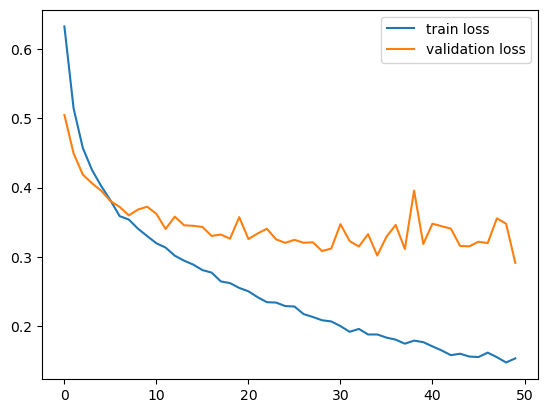

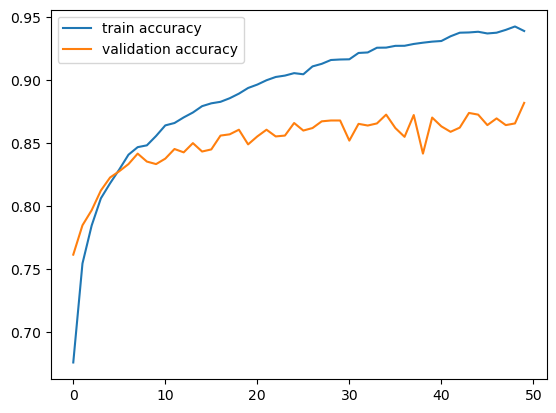

In [19]:
plt.plot(history_x.history['loss'], label='train loss')
plt.plot(history_x.history['val_loss'], label='validation loss')
plt.legend()
plt.show()


plt.plot(history_x.history['accuracy'], label='train accuracy')
plt.plot(history_x.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 552ms/step


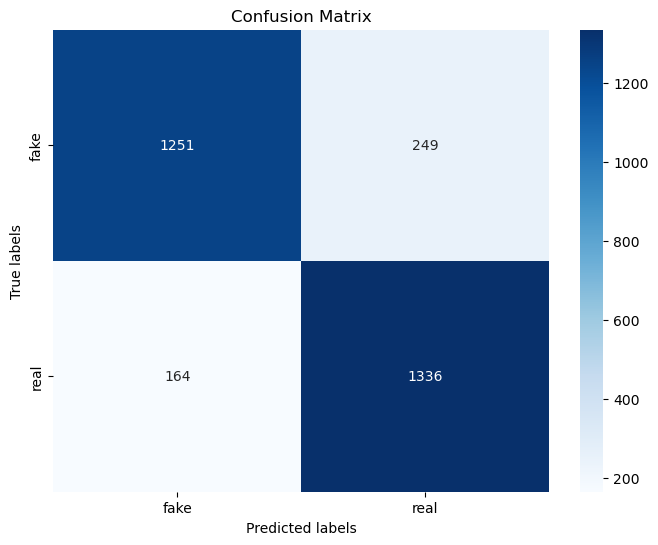

In [20]:
predictions = Xception_model.predict(test_gen)
predicted_labels = np.where(predictions > 0.5, 1, 0)
true_labels = test_gen.classes

conf_matrix = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices,
            yticklabels=test_gen.class_indices)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [21]:
class_names = list(test_gen.class_indices.keys())
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

        fake       0.88      0.83      0.86      1500
        real       0.84      0.89      0.87      1500

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



## EfficientNet

In [14]:
IMG_SIZE, BATCH_SIZE = 224, 32

In [15]:
def build_model():
    base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3) 
    )
    base.trainable = False 
    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)
    x = Dense(1024, activation='swish')(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [16]:
model = build_model()
history = model.fit(
    train_gen224,
    epochs=50, 
    validation_data=val_gen224,
)

I0000 00:00:1745972198.534901 1820882 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14784 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 7.0
/share/pkg.8/academic-ml/spring-2025/install/spring-2025-tf/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1745972216.908175 1821074 service.cc:148] XLA service 0x151ff0016a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745972216.908434 1821074 service.cc:156]   StreamExecutor device (0): Tesla V100-PCIE-16GB, Compute Capability 7.0
I0000 00:00:1745972218.616148 1821074 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/313 ━━━━━━━━━━━━━━━━━━━━ 1:54:46 22s/step - accuracy: 0.5312 - loss: 0.7824

I0000 00:00:1745972228.724810 1821074 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 624s 2s/step - accuracy: 0.6733 - loss: 0.6309 - val_accuracy: 0.7820 - val_loss: 0.4638
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 243s 778ms/step - accuracy: 0.7736 - loss: 0.4867 - val_accuracy: 0.8160 - val_loss: 0.4051
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 237s 756ms/step - accuracy: 0.8016 - loss: 0.4365 - val_accuracy: 0.8167 - val_loss: 0.4048
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 244s 778ms/step - accuracy: 0.8084 - loss: 0.4166 - val_accuracy: 0.8260 - val_loss: 0.3791
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 243s 776ms/step - accuracy: 0.8207 - loss: 0.3955 - val_accuracy: 0.8393 - val_loss: 0.3511
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 243s 776ms/step - accuracy: 0.8282 - loss: 0.3800 - val_accuracy: 0.8437 - val_loss: 0.3584
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 243s 777ms/step - accuracy: 0.8444 - loss: 0.3538 - val_accuracy: 0.8530 - val_loss: 0.3420
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 245s 782ms/step - accuracy: 0.8492 - loss: 0.3421 

In [17]:
test_loss, test_accuracy = model.evaluate(test_gen224)
print(f'Loss: {test_loss}, Accuracy: {test_accuracy}')

47/47 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.9098 - loss: 0.2350   
Loss: 0.2584148049354553, Accuracy: 0.8983333110809326


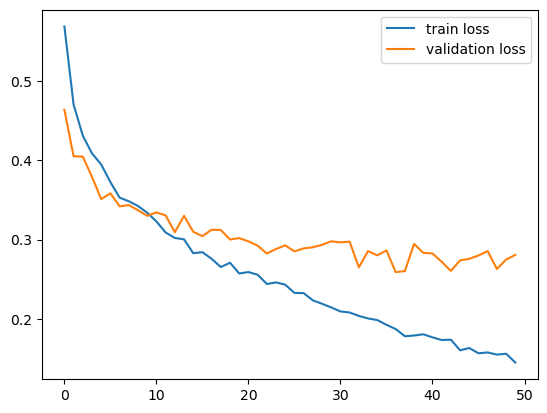

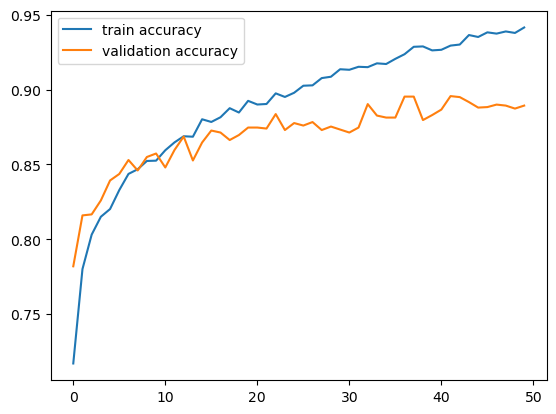

In [18]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 39s 730ms/step


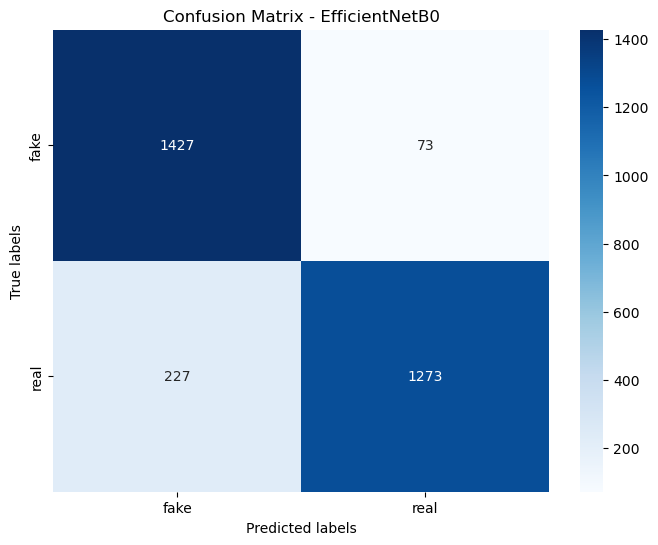

In [19]:
predictions = model.predict(test_gen224)
predicted_labels = np.where(predictions > 0.5, 1, 0)
true_labels = test_gen224.classes

conf_matrix = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_gen224.class_indices.keys()),
            yticklabels=list(test_gen224.class_indices.keys()))
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix - EfficientNetB0')
plt.show()

In [20]:
class_names = list(test_gen224.class_indices.keys())
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print("Classification Report (EfficientNetB0):")
print(report)

Classification Report (EfficientNetB0):
              precision    recall  f1-score   support

        fake       0.86      0.95      0.90      1500
        real       0.95      0.85      0.89      1500

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



### Fine-tuning

In [23]:
warmup_learning_rate = 1e-4
finetune_learning_rate = 1e-5
dropout_rate = 0.5
warmup_freeze_ratio = 1.0   # freeze all layers
finetune_freeze_ratio = 0.7 # unfreeze top 30%
batch_size = 32

In [24]:
def build_efficientnet_tuning(learning_rate=0.001, dropout_rate=0.5, freeze_layers=0.8):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    
    total_layers = len(base_model.layers)
    freeze_until = int(total_layers * freeze_layers)
    for i, layer in enumerate(base_model.layers):
        layer.trainable = i >= freeze_until


    x = GlobalAveragePooling2D()(base_model.output)
    x = BatchNormalization()(x)
    x = Dense(1024, activation='swish')(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [27]:
train_data_generator_tuned = gen_data.flow_from_dataframe(
    dataframe=train_small,
    directory=base_path,
    x_col='path',
    y_col='label_str',
    color_mode="rgb",
    target_size=(224, 224),
    class_mode="binary",
    batch_size=batch_size,
    shuffle=True
)

validation_data_generator_tuned = gen_data.flow_from_dataframe(
    dataframe=val_small,
    directory=base_path,
    x_col='path',
    y_col='label_str',
    color_mode="rgb",
    target_size=(224, 224),
    class_mode="binary",
    batch_size=batch_size,
    shuffle=True
)

test_data_generator_tuned = gen_data.flow_from_dataframe(
    dataframe=test_small,
    directory=base_path,
    x_col='path',
    y_col='label_str',
    color_mode="rgb",
    target_size=(224, 224),
    class_mode="binary",
    batch_size=batch_size,
    shuffle=False
)

Found 20000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.


In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [30]:
warmup_model = build_efficientnet_tuning(
    learning_rate=warmup_learning_rate,
    dropout_rate=dropout_rate,
    freeze_layers=warmup_freeze_ratio
)

print("Warm-up Training (freeze all EfficientNet layers)...")
warmup_model.fit(
    train_gen224,
    epochs=5,
    validation_data=val_gen224,
    callbacks=[early_stopping, reduce_lr]
)



🔧 Warm-up Training (freeze all EfficientNet layers)...


/share/pkg.8/academic-ml/spring-2025/install/spring-2025-tf/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


E0000 00:00:1746038892.381876 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746038892.469305 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.6809 - loss: 0.6234  

E0000 00:00:1746039057.783852 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746039057.871306 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


313/313 ━━━━━━━━━━━━━━━━━━━━ 176s 524ms/step - accuracy: 0.6810 - loss: 0.6232 - val_accuracy: 0.7803 - val_loss: 0.4708 - learning_rate: 1.0000e-04
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 152s 484ms/step - accuracy: 0.7710 - loss: 0.4845 - val_accuracy: 0.8073 - val_loss: 0.4142 - learning_rate: 1.0000e-04
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 152s 485ms/step - accuracy: 0.8013 - loss: 0.4373 - val_accuracy: 0.8273 - val_loss: 0.3815 - learning_rate: 1.0000e-04
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 152s 484ms/step - accuracy: 0.8112 - loss: 0.4128 - val_accuracy: 0.8317 - val_loss: 0.3840 - learning_rate: 1.0000e-04
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 152s 487ms/step - accuracy: 0.8209 - loss: 0.3957 - val_accuracy: 0.8340 - val_loss: 0.3676 - learning_rate: 1.0000e-04


In [31]:
finetune_model = build_efficientnet_tuning(
    learning_rate=finetune_learning_rate,
    dropout_rate=dropout_rate,
    freeze_layers=finetune_freeze_ratio
)

print(" Fine-tuning (unfreeze top EfficientNet layers)...")
history_finetune = finetune_model.fit(
    train_gen224,
    epochs=20,
    validation_data=val_gen224,
    callbacks=[early_stopping, reduce_lr]
)


🎯 Fine-tuning (unfreeze top EfficientNet layers)...
Epoch 1/20


E0000 00:00:1746039679.660424 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746039679.749886 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746039679.917954 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746039680.007140 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


180/313 ━━━━━━━━━━━━━━━━━━━━ 56s 422ms/step - accuracy: 0.5451 - loss: 0.7671 

E0000 00:00:1746039763.502324 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1746039763.591278 3186700 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


313/313 ━━━━━━━━━━━━━━━━━━━━ 181s 526ms/step - accuracy: 0.5711 - loss: 0.7386 - val_accuracy: 0.7293 - val_loss: 0.5272 - learning_rate: 1.0000e-05
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 154s 492ms/step - accuracy: 0.7203 - loss: 0.5668 - val_accuracy: 0.7913 - val_loss: 0.4371 - learning_rate: 1.0000e-05
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 152s 485ms/step - accuracy: 0.7703 - loss: 0.4841 - val_accuracy: 0.8277 - val_loss: 0.3860 - learning_rate: 1.0000e-05
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 152s 485ms/step - accuracy: 0.8068 - loss: 0.4256 - val_accuracy: 0.8490 - val_loss: 0.3489 - learning_rate: 1.0000e-05
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 153s 488ms/step - accuracy: 0.8338 - loss: 0.3739 - val_accuracy: 0.8560 - val_loss: 0.3240 - learning_rate: 1.0000e-05
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 154s 491ms/step - accuracy: 0.8574 - loss: 0.3348 - val_accuracy: 0.8750 - val_loss: 0.2906 - learning_rate: 1.0000e-05
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 153s 489ms/

In [35]:
test_loss, test_accuracy = finetune_model.evaluate(test_data_generator_tuned)
print(f" Final Fine-Tuned Model Evaluation:\nLoss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}")

finetune_model.save("efficientnet_finetuned_manual.h5")


94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 213ms/step - accuracy: 0.4982 - loss: 1.6242


 Final Fine-Tuned Model Evaluation:
Loss: 1.6190, Accuracy: 0.5000


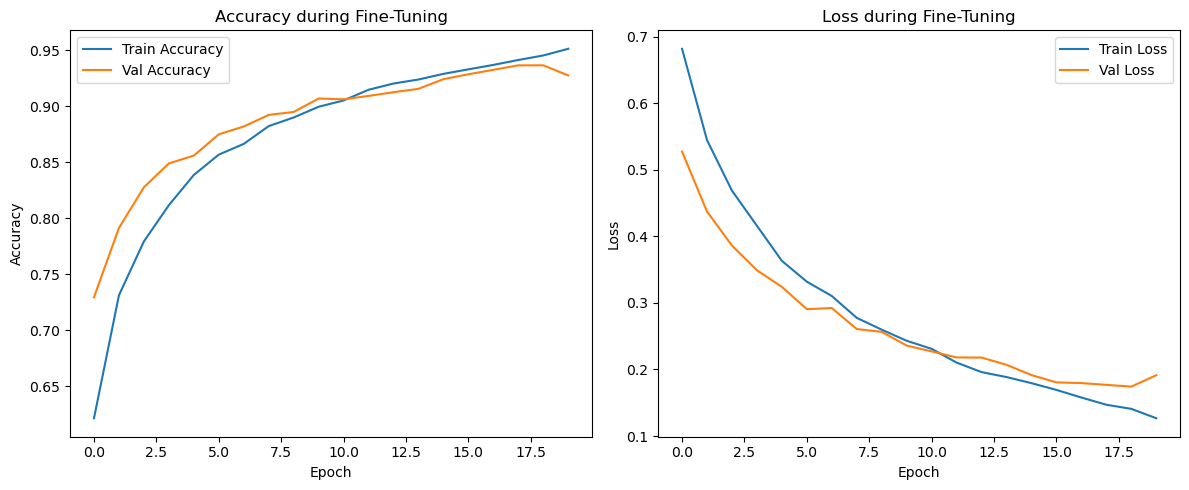

In [36]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy during Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_finetune.history['loss'], label='Train Loss')
plt.plot(history_finetune.history['val_loss'], label='Val Loss')
plt.title('Loss during Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()